# Pareto Ant Colony Optimization (PACO)

Demonstration notebook for dual-pheromone Pareto ACO on the multi-objective CVRP (**Representation A — giant tour**). Hyperparameters are reduced for demo speed (Layer 5 uses repeated runs at full strength).

## 1. Setup

In [1]:
import matplotlib.pyplot as plt

from cvrp.experiment.swarm.paco_executer import PACOExecuter
from cvrp.experiment.visualization import (
    plot_instance,
    plot_routes,
    plot_pareto_front,
    plot_convergence,
)

INSTANCE_NAME = "X-n101-k25.vrp"
N_ANTS = 30
ARCHIVE_SIZE = 80
MAX_ITERATIONS = 80
N_REPEAT_DEMO = 8

## 2. Load instance

Plot the depot and customers to confirm the instance loaded correctly.

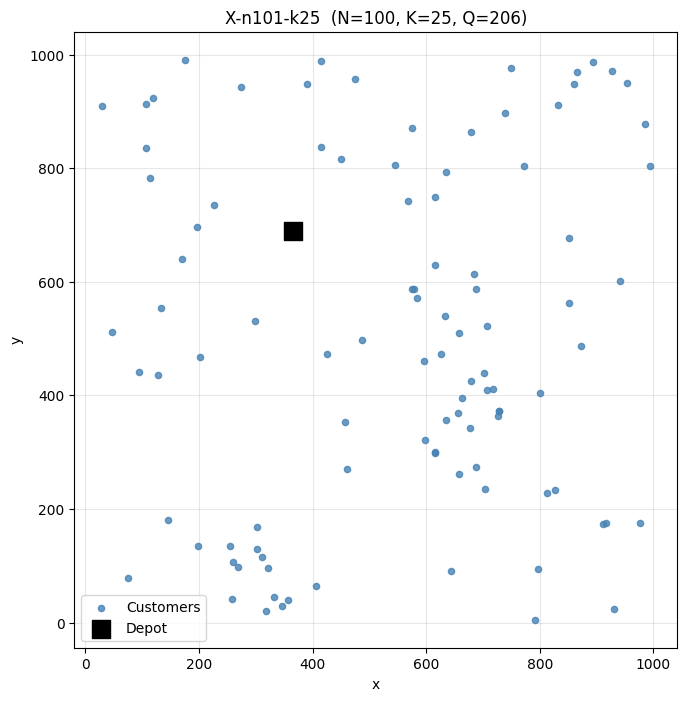

In [2]:
executer = PACOExecuter(instances_folder="data/")
benchmark = executer._build_benchmark(INSTANCE_NAME)
instance = benchmark.instance

plot_instance(instance)
plt.show()

## 3. Single run

One execution of PACO with a fixed seed. The colony maintains an external Pareto archive (approximated front under archive size limits).

In [3]:
paco = executer.run_single_experiment(
    INSTANCE_NAME,
    seed=0,
    n_ants=N_ANTS,
    archive_size=ARCHIVE_SIZE,
    max_iterations=MAX_ITERATIONS,
)

print(f"Pareto front size (archive): {len(paco.final_archive)}")
print(f"Iterations executed:       {paco.num_generations}")
print(f"Total evaluations:         {paco.num_evaluations}")

Pareto front size (archive): 2
Iterations executed:       80
Total evaluations:         2400


## 4. Visualize results

### 4.1 Pareto front

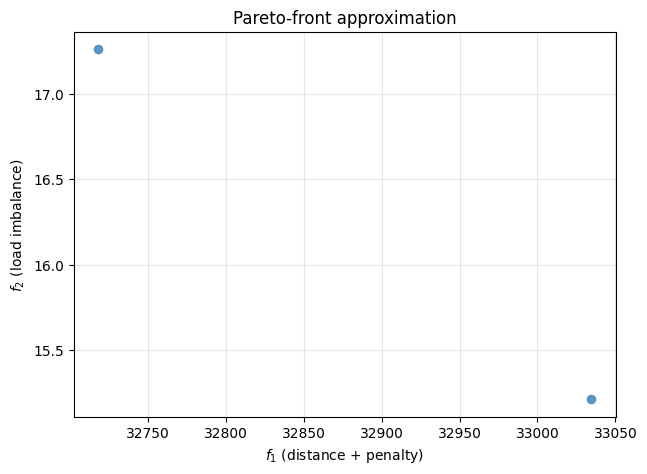

In [4]:
plot_pareto_front(paco.final_archive)
plt.show()

### 4.2 Routes for the minimum-distance solution

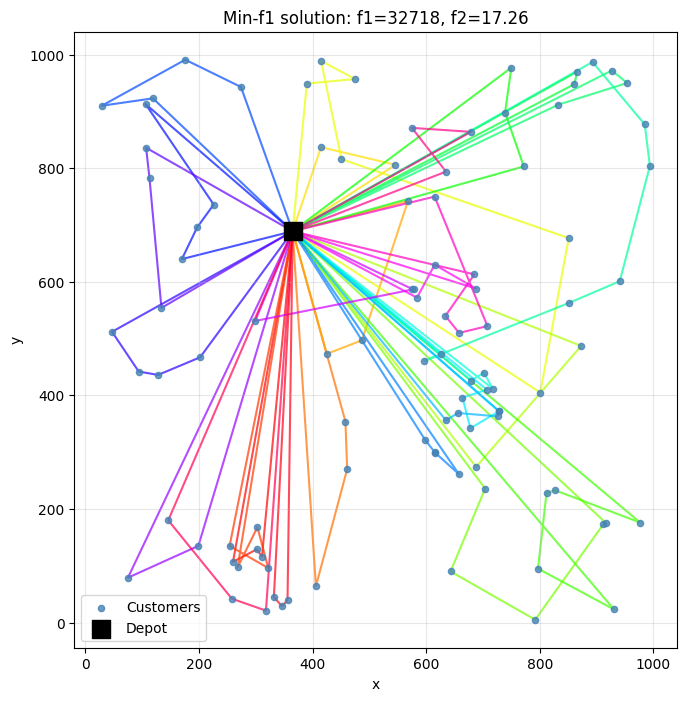

In [5]:
best_f1 = min(paco.final_archive, key=lambda ind: ind.fitness.values[0])
routes = benchmark.decoder.decode(best_f1.candidate)

ax = plot_instance(instance)
plot_routes(routes, instance, ax=ax)
ax.set_title(
    f"Min-f1 solution: f1={best_f1.fitness.values[0]:.0f}, "
    f"f2={best_f1.fitness.values[1]:.2f}"
)
plt.show()

### 4.3 Convergence

Best/median f1 per iteration over ant populations (same proxy semantics as ``run_nsga2.ipynb``).

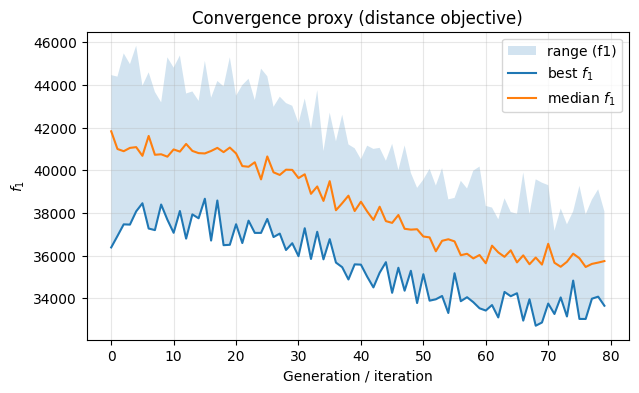

In [6]:
plot_convergence(paco.history)
plt.show()

## 5. Repeated runs

Aggregate several seeds into a long-format ``DataFrame`` (one row per archive member per run).

In [7]:
df = executer.run_repeated_experiment(
    INSTANCE_NAME,
    n_repeat=N_REPEAT_DEMO,
    n_ants=N_ANTS,
    archive_size=ARCHIVE_SIZE,
    max_iterations=MAX_ITERATIONS,
)

df.head()

X-n101-k25.vrp - run 1/8
X-n101-k25.vrp - run 2/8
X-n101-k25.vrp - run 3/8
X-n101-k25.vrp - run 4/8
X-n101-k25.vrp - run 5/8
X-n101-k25.vrp - run 6/8
X-n101-k25.vrp - run 7/8
X-n101-k25.vrp - run 8/8


,run,solution_idx,f1,f2,n_evaluations,n_generations
0,0,0,32717.995809,17.260718,2400,80
1,0,1,33034.615114,15.212902,2400,80
2,1,0,34761.075251,14.157415,2400,80
3,1,1,32966.108893,17.373425,2400,80
4,1,2,32833.994986,18.602226,2400,80


### 5.1 Summary across runs

In [8]:
front_sizes = df.groupby("run").size()
print(
    f"Front size (mean / std / min / max): "
    f"{front_sizes.mean():.1f} / {front_sizes.std():.1f} / "
    f"{front_sizes.min()} / {front_sizes.max()}"
)
print(f"Best f1 across all runs: {df['f1'].min():.2f}")
print(f"Best f2 across all runs: {df['f2'].min():.4f}")
print(f"Total runs: {df['run'].nunique()}")

Front size (mean / std / min / max): 4.6 / 1.4 / 2 / 6
Best f1 across all runs: 31329.50
Best f2 across all runs: 13.7764
Total runs: 8


## 6. Run-all demo (writes ``tmp/paco_demo/``)

In [9]:
demo_executer = PACOExecuter(instances_folder="data/")
demo_executer.instances = [INSTANCE_NAME]

demo_executer.run_all_experiments(
    "tmp/paco_demo/",
    n_repeat=3,
    overwrite=True,
    n_ants=N_ANTS,
    archive_size=ARCHIVE_SIZE,
    max_iterations=MAX_ITERATIONS,
)

Running experiments for X-n101-k25.vrp
X-n101-k25.vrp - run 1/3
X-n101-k25.vrp - run 2/3
X-n101-k25.vrp - run 3/3
Saved to tmp/paco_demo/X-n101-k25.csv
